In [1]:
import pandas as pd
import numpy as np
import re

from extraction.texts import model_loader, text_encoding

In [2]:
df = pd.read_csv('data/texts/hate_speech/labeled_data.csv')
df = df[["tweet", 'class']]

df['class'] = df['class'].replace({
                            1:1,
                            2:1
                        })

df = pd.concat([
    df[df["class"] == 0].head(2000),
    df[df["class"] == 1].head(8000)
]).reset_index(drop=True)

df["tweet"] = (
    df["tweet"].apply(lambda x: re.sub(r"[^A-Za-z0-9]", " ", 
                                             x, count=0, flags=0))
            .apply(lambda x: re.findall(r"[A-Za-z0-9]+", x))
            .apply(lambda x: " ".join(x))
)

In [3]:
texts = df["tweet"].to_list()

In [4]:
model, model_code = model_loader('mps', model_code='e5')
text_vectors = text_encoding(texts, model, model_code)

Batches:   0%|          | 0/295 [00:00<?, ?it/s]

In [5]:
from sklearn.model_selection import train_test_split
from training.kfold_train import stratified_kfold_train_val

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, classification_report

In [6]:
x, y = text_vectors, df["class"].to_numpy()
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    stratify=y,
                                                    test_size=0.2)

In [7]:
log_reg = LogisticRegression(
    penalty='l2',          # Use L2 (Ridge) regularization
    C=0.5,                 # Slightly stronger regularization than default
    solver='liblinear',        # Standard efficient solver
    max_iter=1000,         # Increased to guarantee optimization convergence
    random_state=42,
    class_weight='balanced'
)

stratified_kfold_train_val(5,
                           0.35,
                           log_reg,
                           x_train,
                           y_train)

Starting 5-Fold Stratified Cross-Validation...

sss
--- Performance Analysis at Threshold (0.35) ---
Custom Precision Score: 0.9182 (When flagged positive, accuracy is 91.82%)
Custom Recall Score:    0.9477 (Captured 94.77% of all true positive cases)
sss
--- Performance Analysis at Threshold (0.35) ---
Custom Precision Score: 0.9164 (When flagged positive, accuracy is 91.64%)
Custom Recall Score:    0.9336 (Captured 93.36% of all true positive cases)
sss
--- Performance Analysis at Threshold (0.35) ---
Custom Precision Score: 0.9138 (When flagged positive, accuracy is 91.38%)
Custom Recall Score:    0.9437 (Captured 94.38% of all true positive cases)
sss
--- Performance Analysis at Threshold (0.35) ---
Custom Precision Score: 0.9135 (When flagged positive, accuracy is 91.35%)
Custom Recall Score:    0.9406 (Captured 94.06% of all true positive cases)
sss
--- Performance Analysis at Threshold (0.35) ---
Custom Precision Score: 0.9224 (When flagged positive, accuracy is 92.24%)
Custom R

In [14]:
log_reg = LogisticRegression(
    penalty='l2',          # Use L2 (Ridge) regularization
    C=0.5,                 # Slightly stronger regularization than default
    solver='liblinear',        # Standard efficient solver
    max_iter=1000,         # Increased to guarantee optimization convergence
    random_state=42,
    class_weight='balanced'
)
threshold = 0.35

log_reg.fit(x_train, y_train)
test_probabilities = log_reg.predict_proba(x_test)[:, 1]
predictions = (test_probabilities >= threshold).astype(int)

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.55      0.53      0.54       286
           1       0.92      0.92      0.92      1600

    accuracy                           0.86      1886
   macro avg       0.73      0.73      0.73      1886
weighted avg       0.86      0.86      0.86      1886

[[ 153  133]
 [ 125 1475]]


In [15]:
from evaluation.visualization import confusion_matrix_viz

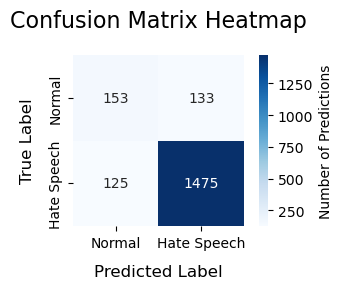

In [16]:
confusion_matrix_viz(y_test,
                     predictions,
                     class_names=['Normal', 'Hate Speech'])

In [17]:
import joblib

In [18]:
joblib.dump(log_reg, open("model/hate_speech.jobllib", 'wb'))